In [1]:
# ============================================================
# PHASE 17 — CELL 1
# Imports
# ============================================================

from pathlib import Path
import os
import json
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
)

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Python:", os.sys.version)
print("TensorFlow:", tf.__version__)
print("Phase 17 imports successful.")

Python: 3.12.0 (tags/v3.12.0:0fb18b0, Oct  2 2023, 13:03:39) [MSC v.1935 64 bit (AMD64)]
TensorFlow: 2.20.0
Phase 17 imports successful.


In [2]:
# ============================================================
# PHASE 17 — CELL 2
# Project root
# ============================================================

PROJECT_ROOT = Path(
    r"D:\downloads\misleading-health-infographic-detection"
)

assert PROJECT_ROOT.exists(), (
    f"Project root not found:\n{PROJECT_ROOT}"
)

print("PROJECT_ROOT:")
print(PROJECT_ROOT)

PROJECT_ROOT:
D:\downloads\misleading-health-infographic-detection


In [3]:
# ============================================================
# PHASE 17 — CELL 3
# Input paths
# ============================================================

OUTPUTS_DIR = PROJECT_ROOT / "outputs"

PHASE11_DIR = (
    OUTPUTS_DIR / "phase11"
)

PHASE11_DATASET_DIR = (
    PHASE11_DIR / "datasets"
)

PHASE11_METRICS_DIR = (
    PHASE11_DIR / "metrics"
)

PHASE11_CHECKPOINT_DIR = (
    PHASE11_DIR / "checkpoints"
)

PHASE16_DIR = (
    OUTPUTS_DIR / "phase16"
)

PHASE16_MANIFEST_DIR = (
    PHASE16_DIR / "manifests"
)

print("Phase 11:")
print(PHASE11_DIR)

print("\nPhase 16:")
print(PHASE16_DIR)

Phase 11:
D:\downloads\misleading-health-infographic-detection\outputs\phase11

Phase 16:
D:\downloads\misleading-health-infographic-detection\outputs\phase16


In [4]:
# ============================================================
# PHASE 17 — CELL 4
# Output directories
# ============================================================

PHASE17_DIR = (
    OUTPUTS_DIR / "phase17"
)

ABLATION_DIR = (
    PHASE17_DIR / "ablation_models"
)

METRICS_DIR = (
    PHASE17_DIR / "metrics"
)

PLOTS_DIR = (
    PHASE17_DIR / "visualizations"
)

REPORT_DIR = (
    PHASE17_DIR / "reports"
)

MANIFEST_DIR = (
    PHASE17_DIR / "manifests"
)

for directory in [
    PHASE17_DIR,
    ABLATION_DIR,
    METRICS_DIR,
    PLOTS_DIR,
    REPORT_DIR,
    MANIFEST_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True
    )

print("Phase 17 directories created.")

Phase 17 directories created.


In [5]:
# ============================================================
# PHASE 17 — CELL 5
# Verify Phase 11 datasets
# ============================================================

TRAIN_FILE = (
    PHASE11_DATASET_DIR
    / "final_train.csv"
)

VAL_FILE = (
    PHASE11_DATASET_DIR
    / "final_validation.csv"
)

TEST_FILE = (
    PHASE11_DATASET_DIR
    / "final_test.csv"
)

for file_path in [
    TRAIN_FILE,
    VAL_FILE,
    TEST_FILE,
]:

    print(
        "✓" if file_path.exists() else "✗",
        file_path
    )

assert TRAIN_FILE.exists()
assert VAL_FILE.exists()
assert TEST_FILE.exists()

print("\n✓ Phase 11 datasets found.")

✓ D:\downloads\misleading-health-infographic-detection\outputs\phase11\datasets\final_train.csv
✓ D:\downloads\misleading-health-infographic-detection\outputs\phase11\datasets\final_validation.csv
✓ D:\downloads\misleading-health-infographic-detection\outputs\phase11\datasets\final_test.csv

✓ Phase 11 datasets found.


In [6]:
# ============================================================
# PHASE 17 — CELL 6
# Load Phase 11 datasets
# ============================================================

train_df = pd.read_csv(
    TRAIN_FILE
)

val_df = pd.read_csv(
    VAL_FILE
)

test_df = pd.read_csv(
    TEST_FILE
)

print(
    "Train:",
    train_df.shape
)

print(
    "Validation:",
    val_df.shape
)

print(
    "Test:",
    test_df.shape
)

Train: (4016, 15)
Validation: (803, 15)
Test: (803, 15)


In [7]:
# ============================================================
# PHASE 17 — CELL 7
# Dataset inspection
# ============================================================

print("Train columns:")
print(
    list(train_df.columns)
)

print("\nLabel distributions:")

print(
    "\nTRAIN"
)

print(
    train_df["label"]
    .value_counts()
    .sort_index()
)

print(
    "\nVALIDATION"
)

print(
    val_df["label"]
    .value_counts()
    .sort_index()
)

print(
    "\nTEST"
)

print(
    test_df["label"]
    .value_counts()
    .sort_index()
)

Train columns:
['record_key', 'subset', 'record_id', 'label', 'source', 'is_english', 'text', 'split', 'image_path', 'local_path', 'resolved_image_path', 'image_hash', 'text_key', 'text_hash', 'group_id']

Label distributions:

TRAIN
label
0     758
1    3258
Name: count, dtype: int64

VALIDATION
label
0    151
1    652
Name: count, dtype: int64

TEST
label
0    151
1    652
Name: count, dtype: int64


In [8]:
# ============================================================
# PHASE 17 — CELL 8
# Leakage verification
# ============================================================

def overlap_count(
    df_a,
    df_b,
    column
):

    if column not in df_a.columns:
        return None

    if column not in df_b.columns:
        return None

    a = set(
        df_a[column]
        .dropna()
        .astype(str)
    )

    b = set(
        df_b[column]
        .dropna()
        .astype(str)
    )

    return len(
        a.intersection(b)
    )


leakage_checks = {

    "train_val_image_overlap":
        overlap_count(
            train_df,
            val_df,
            "image_hash"
        ),

    "train_test_image_overlap":
        overlap_count(
            train_df,
            test_df,
            "image_hash"
        ),

    "val_test_image_overlap":
        overlap_count(
            val_df,
            test_df,
            "image_hash"
        ),

    "train_val_text_overlap":
        overlap_count(
            train_df,
            val_df,
            "text_hash"
        ),

    "train_test_text_overlap":
        overlap_count(
            train_df,
            test_df,
            "text_hash"
        ),

    "val_test_text_overlap":
        overlap_count(
            val_df,
            test_df,
            "text_hash"
        ),

    "train_val_group_overlap":
        overlap_count(
            train_df,
            val_df,
            "group_id"
        ),

    "train_test_group_overlap":
        overlap_count(
            train_df,
            test_df,
            "group_id"
        ),

    "val_test_group_overlap":
        overlap_count(
            val_df,
            test_df,
            "group_id"
        ),
}

print(
    json.dumps(
        leakage_checks,
        indent=4
    )
)

assert all(
    value == 0
    for value in leakage_checks.values()
    if value is not None
)

print(
    "\n✓ Leakage audit passed."
)

{
    "train_val_image_overlap": 0,
    "train_test_image_overlap": 0,
    "val_test_image_overlap": 0,
    "train_val_text_overlap": 0,
    "train_test_text_overlap": 0,
    "val_test_text_overlap": 0,
    "train_val_group_overlap": 0,
    "train_test_group_overlap": 0,
    "val_test_group_overlap": 0
}

✓ Leakage audit passed.


In [9]:
# ============================================================
# PHASE 17 — CELL 9
# Load Phase 11 final metrics
# ============================================================

PHASE11_METRICS_FILE = (
    PHASE11_METRICS_DIR
    / "final_test_metrics.json"
)

assert PHASE11_METRICS_FILE.exists(), (
    "Phase 11 final_test_metrics.json not found."
)

with open(
    PHASE11_METRICS_FILE,
    "r",
    encoding="utf-8"
) as f:

    phase11_metrics = json.load(f)

print(
    json.dumps(
        phase11_metrics,
        indent=4
    )
)

{
    "threshold": 0.21999999999999995,
    "accuracy": 0.8991282689912827,
    "precision": 0.9538950715421304,
    "recall": 0.9202453987730062,
    "f1_score": 0.936768149882904,
    "roc_auc": 0.9345975703896315,
    "pr_auc": 0.9822670079517324
}


In [11]:
# ============================================================
# PHASE 17 — CELL 10
# Reconstruct Phase 11 multimodal model and load weights
# ============================================================

from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0


# ------------------------------------------------------------
# 1. Correct Phase 11 checkpoint
# ------------------------------------------------------------

MULTIMODAL_WEIGHTS_PATH = (
    PHASE11_CHECKPOINT_DIR
    / "best_multimodal_model.weights.h5"
)

print(
    "Looking for Phase 11 weights at:"
)

print(
    MULTIMODAL_WEIGHTS_PATH
)

assert MULTIMODAL_WEIGHTS_PATH.exists(), (
    f"Phase 11 weights not found:\n"
    f"{MULTIMODAL_WEIGHTS_PATH}"
)


# ------------------------------------------------------------
# 2. Recreate the Phase 11 text vectorizer
# ------------------------------------------------------------

MAX_TOKENS = 20000
SEQUENCE_LENGTH = 300

text_vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=SEQUENCE_LENGTH,
    standardize="lower_and_strip_punctuation"
)

# IMPORTANT:
# Fit ONLY on the Phase 11 training split.
text_vectorizer.adapt(
    train_df[
        "text"
    ]
    .fillna("")
    .astype(str)
    .values
)

print(
    "Vocabulary size:",
    len(
        text_vectorizer.get_vocabulary()
    )
)


# ------------------------------------------------------------
# 3. Recreate the exact Phase 11 multimodal architecture
# ------------------------------------------------------------

image_input = layers.Input(
    shape=(224, 224, 3),
    name="image"
)


# Image branch
image_base = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

image_base.trainable = False

image_features = image_base(
    image_input,
    training=False
)

image_features = (
    layers.GlobalAveragePooling2D()
    (image_features)
)

image_features = layers.Dense(
    128,
    activation="relu"
)(image_features)


# Text branch
text_input = layers.Input(
    shape=(),
    dtype=tf.string,
    name="text"
)

text_tokens = text_vectorizer(
    text_input
)

text_features = layers.Embedding(
    input_dim=MAX_TOKENS,
    output_dim=128,
    mask_zero=True
)(text_tokens)

text_features = (
    layers.Bidirectional(
        layers.LSTM(64)
    )
    (text_features)
)

text_features = layers.Dense(
    128,
    activation="relu"
)(text_features)


# Fusion
combined = layers.Concatenate()([
    image_features,
    text_features
])

combined = layers.Dense(
    128,
    activation="relu"
)(combined)

combined = layers.Dropout(
    0.4
)(combined)

combined = layers.Dense(
    64,
    activation="relu"
)(combined)

combined = layers.Dropout(
    0.3
)(combined)


# Output
output = layers.Dense(
    1,
    activation="sigmoid",
    name="output"
)(combined)


multimodal_model = Model(
    inputs=[
        image_input,
        text_input
    ],
    outputs=output
)


# ------------------------------------------------------------
# 4. Compile
# ------------------------------------------------------------

multimodal_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(
            name="precision"
        ),
        tf.keras.metrics.Recall(
            name="recall"
        ),
        tf.keras.metrics.AUC(
            name="auc"
        )
    ]
)


# ------------------------------------------------------------
# 5. Load the Phase 11 trained weights
# ------------------------------------------------------------

multimodal_model.load_weights(
    MULTIMODAL_WEIGHTS_PATH
)


print()
print("=" * 70)
print("✓ PHASE 11 MULTIMODAL MODEL LOADED")
print("=" * 70)

print(
    "\nWeights:",
    MULTIMODAL_WEIGHTS_PATH
)

print(
    "\nArchitecture:"
)

print(
    "  Image encoder : EfficientNetB0"
)

print(
    "  Image projection : Dense(128)"
)

print(
    "  Text encoder : TextVectorization + Embedding + BiLSTM"
)

print(
    "  Text projection : Dense(128)"
)

print(
    "  Fusion : Concatenate"
)

print(
    "  Classifier : Dense(128) → Dense(64) → Sigmoid"
)

print(
    "\n✓ Ready for Phase 17 evaluation."
)

Looking for Phase 11 weights at:
D:\downloads\misleading-health-infographic-detection\outputs\phase11\checkpoints\best_multimodal_model.weights.h5
Vocabulary size: 20000

✓ PHASE 11 MULTIMODAL MODEL LOADED

Weights: D:\downloads\misleading-health-infographic-detection\outputs\phase11\checkpoints\best_multimodal_model.weights.h5

Architecture:
  Image encoder : EfficientNetB0
  Image projection : Dense(128)
  Text encoder : TextVectorization + Embedding + BiLSTM
  Text projection : Dense(128)
  Fusion : Concatenate
  Classifier : Dense(128) → Dense(64) → Sigmoid

✓ Ready for Phase 17 evaluation.


In [14]:
# ============================================================
# PHASE 17 — CELL 11
# Prepare image/text inputs
# Rebuild image paths from the current project location
# ============================================================

print("=" * 70)
print("PHASE 17 — DATA PREPARATION")
print("=" * 70)


# ------------------------------------------------------------
# 1. Verify required columns
# ------------------------------------------------------------

required_columns = [
    "label",
    "text",
    "image_path"
]

for column in required_columns:

    assert column in train_df.columns, (
        f"Missing column in train_df: {column}"
    )

    assert column in val_df.columns, (
        f"Missing column in val_df: {column}"
    )

    assert column in test_df.columns, (
        f"Missing column in test_df: {column}"
    )


print("✓ Required columns found.")


# ------------------------------------------------------------
# 2. Clean text
# ------------------------------------------------------------

train_df["text"] = (
    train_df["text"]
    .fillna("")
    .astype(str)
)

val_df["text"] = (
    val_df["text"]
    .fillna("")
    .astype(str)
)

test_df["text"] = (
    test_df["text"]
    .fillna("")
    .astype(str)
)


# ------------------------------------------------------------
# 3. Convert labels to integers
# ------------------------------------------------------------

train_df["label"] = (
    train_df["label"]
    .astype(int)
)

val_df["label"] = (
    val_df["label"]
    .astype(int)
)

test_df["label"] = (
    test_df["label"]
    .astype(int)
)


# ------------------------------------------------------------
# 4. Locate Phase 10 image directory
# ------------------------------------------------------------

PHASE10_IMAGE_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "phase10"
    / "images"
)


print()
print("Phase 10 image directory:")
print(PHASE10_IMAGE_DIR)


assert PHASE10_IMAGE_DIR.exists(), (
    "Phase 10 image directory was not found:\n"
    f"{PHASE10_IMAGE_DIR}"
)


print("✓ Phase 10 image directory exists.")


# ------------------------------------------------------------
# 5. Convert Phase 11 image_path to current image path
# ------------------------------------------------------------

def resolve_current_image_path(image_path):

    if pd.isna(image_path):
        return ""

    image_path = str(
        image_path
    ).strip()

    # Normalize Windows / Linux separators
    image_path = image_path.replace(
        "\\",
        "/"
    )

    image_path_obj = Path(
        image_path
    )

    # --------------------------------------------------------
    # Expected Phase 11 format:
    #
    # human_data/MM-COVID19/0_1.jpg
    #
    # Current Phase 10 structure:
    #
    # outputs/phase10/images/MM-COVID19/0_1.jpg
    # --------------------------------------------------------

    parts = image_path_obj.parts

    if (
        len(parts) >= 2
        and parts[0].lower() == "human_data"
    ):

        relative_image_path = Path(
            *parts[1:]
        )

        candidate = (
            PHASE10_IMAGE_DIR
            / relative_image_path
        )

        if candidate.exists():
            return str(candidate)


    # --------------------------------------------------------
    # Fallback:
    # Search for the filename inside Phase 10 images
    # --------------------------------------------------------

    filename = image_path_obj.name

    matches = list(
        PHASE10_IMAGE_DIR.rglob(
            filename
        )
    )

    if len(matches) == 1:
        return str(matches[0])

    if len(matches) > 1:

        # Prefer a path whose parent matches
        # the original image path structure.

        original_parts = set(
            parts[:-1]
        )

        for match in matches:

            if any(
                part in original_parts
                for part in match.parts
            ):

                return str(match)

        return str(matches[0])


    # --------------------------------------------------------
    # Nothing found
    # --------------------------------------------------------

    return ""


# ------------------------------------------------------------
# 6. Build current paths
# ------------------------------------------------------------

train_df["resolved_image_path"] = (
    train_df["image_path"]
    .apply(
        resolve_current_image_path
    )
)

val_df["resolved_image_path"] = (
    val_df["image_path"]
    .apply(
        resolve_current_image_path
    )
)

test_df["resolved_image_path"] = (
    test_df["image_path"]
    .apply(
        resolve_current_image_path
    )
)


# ------------------------------------------------------------
# 7. Check image existence
# ------------------------------------------------------------

def check_image_paths(dataframe):

    return dataframe[
        "resolved_image_path"
    ].apply(
        lambda p:
        bool(p)
        and Path(p).exists()
    )


train_exists = check_image_paths(
    train_df
)

val_exists = check_image_paths(
    val_df
)

test_exists = check_image_paths(
    test_df
)


train_existing = int(
    train_exists.sum()
)

val_existing = int(
    val_exists.sum()
)

test_existing = int(
    test_exists.sum()
)


print()
print("=" * 70)
print("IMAGE EXISTENCE CHECK")
print("=" * 70)

print(
    "Train:",
    train_existing,
    "/",
    len(train_df)
)

print(
    "Validation:",
    val_existing,
    "/",
    len(val_df)
)

print(
    "Test:",
    test_existing,
    "/",
    len(test_df)
)


# ------------------------------------------------------------
# 8. Show examples of resolved paths
# ------------------------------------------------------------

print()
print("=" * 70)
print("SAMPLE RESOLVED PATHS")
print("=" * 70)

print()

for _, row in train_df.head(5).iterrows():

    print(
        "Original :",
        row["image_path"]
    )

    print(
        "Resolved :",
        row["resolved_image_path"]
    )

    print(
        "Exists   :",
        Path(
            row["resolved_image_path"]
        ).exists()
        if row["resolved_image_path"]
        else False
    )

    print("-" * 70)


# ------------------------------------------------------------
# 9. Show missing examples if necessary
# ------------------------------------------------------------

if train_existing < len(train_df):

    print()
    print("=" * 70)
    print("MISSING TRAINING IMAGE EXAMPLES")
    print("=" * 70)

    print(
        train_df.loc[
            ~train_exists,
            [
                "record_key",
                "image_path",
                "resolved_image_path"
            ]
        ]
        .head(20)
        .to_string(index=False)
    )


if val_existing < len(val_df):

    print()
    print("=" * 70)
    print("MISSING VALIDATION IMAGE EXAMPLES")
    print("=" * 70)

    print(
        val_df.loc[
            ~val_exists,
            [
                "record_key",
                "image_path",
                "resolved_image_path"
            ]
        ]
        .head(20)
        .to_string(index=False)
    )


if test_existing < len(test_df):

    print()
    print("=" * 70)
    print("MISSING TEST IMAGE EXAMPLES")
    print("=" * 70)

    print(
        test_df.loc[
            ~test_exists,
            [
                "record_key",
                "image_path",
                "resolved_image_path"
            ]
        ]
        .head(20)
        .to_string(index=False)
    )


# ------------------------------------------------------------
# 10. Final validation
# ------------------------------------------------------------

assert train_existing == len(train_df), (
    "Some training images could not be found "
    "inside outputs/phase10/images."
)

assert val_existing == len(val_df), (
    "Some validation images could not be found "
    "inside outputs/phase10/images."
)

assert test_existing == len(test_df), (
    "Some test images could not be found "
    "inside outputs/phase10/images."
)


print()
print("=" * 70)
print("✓ IMAGE PATHS VERIFIED")
print("✓ TEXT FIELDS PREPARED")
print("✓ LABELS PREPARED")
print("=" * 70)

PHASE 17 — DATA PREPARATION
✓ Required columns found.

Phase 10 image directory:
D:\downloads\misleading-health-infographic-detection\outputs\phase10\images
✓ Phase 10 image directory exists.

IMAGE EXISTENCE CHECK
Train: 4016 / 4016
Validation: 803 / 803
Test: 803 / 803

SAMPLE RESOLVED PATHS

Original : human_data/MM-COVID19/0_1.jpg
Resolved : D:\downloads\misleading-health-infographic-detection\outputs\phase10\images\MM-COVID19\0_1.jpg
Exists   : True
----------------------------------------------------------------------
Original : human_data/MM-COVID19/15_4.jpg
Resolved : D:\downloads\misleading-health-infographic-detection\outputs\phase10\images\MM-COVID19\15_4.jpg
Exists   : True
----------------------------------------------------------------------
Original : human_data/MM-COVID19/2_18.jpg
Resolved : D:\downloads\misleading-health-infographic-detection\outputs\phase10\images\MM-COVID19\2_18.jpg
Exists   : True
---------------------------------------------------------------------

In [15]:
# ============================================================
# PHASE 17 — CELL 12
# Create image datasets
# ============================================================

print("=" * 70)
print("PHASE 17 — IMAGE DATASET CREATION")
print("=" * 70)

IMG_SIZE = (224, 224)
BATCH_SIZE = 16


def load_image(image_path, label):
    """
    Load and preprocess one image.

    EfficientNetB0 already contains its own preprocessing,
    so images are kept in the 0–255 float32 range.
    """

    image = tf.io.read_file(image_path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    )

    label = tf.cast(
        label,
        tf.float32
    )

    return image, label


# ------------------------------------------------------------
# Image-only datasets
# ------------------------------------------------------------

train_image_paths = train_df[
    "resolved_image_path"
].values

train_image_labels = train_df[
    "label"
].values

val_image_paths = val_df[
    "resolved_image_path"
].values

val_image_labels = val_df[
    "label"
].values

test_image_paths = test_df[
    "resolved_image_path"
].values

test_image_labels = test_df[
    "label"
].values


train_image_ds = tf.data.Dataset.from_tensor_slices(
    (
        train_image_paths,
        train_image_labels
    )
)

val_image_ds = tf.data.Dataset.from_tensor_slices(
    (
        val_image_paths,
        val_image_labels
    )
)

test_image_ds = tf.data.Dataset.from_tensor_slices(
    (
        test_image_paths,
        test_image_labels
    )
)


train_image_ds = (
    train_image_ds
    .map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_image_ds = (
    val_image_ds
    .map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_image_ds = (
    test_image_ds
    .map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)


print("✓ Image datasets created.")
print("Image size :", IMG_SIZE)
print("Batch size :", BATCH_SIZE)

PHASE 17 — IMAGE DATASET CREATION
✓ Image datasets created.
Image size : (224, 224)
Batch size : 16


In [16]:
# ============================================================
# PHASE 17 — CELL 12
# Create image datasets
# ============================================================

print("=" * 70)
print("PHASE 17 — IMAGE DATASET CREATION")
print("=" * 70)

IMG_SIZE = (224, 224)
BATCH_SIZE = 16


def load_image(image_path, label):
    """
    Load and preprocess one image.

    EfficientNetB0 already contains its own preprocessing,
    so images are kept in the 0–255 float32 range.
    """

    image = tf.io.read_file(image_path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    )

    label = tf.cast(
        label,
        tf.float32
    )

    return image, label


# ------------------------------------------------------------
# Image-only datasets
# ------------------------------------------------------------

train_image_paths = train_df[
    "resolved_image_path"
].values

train_image_labels = train_df[
    "label"
].values

val_image_paths = val_df[
    "resolved_image_path"
].values

val_image_labels = val_df[
    "label"
].values

test_image_paths = test_df[
    "resolved_image_path"
].values

test_image_labels = test_df[
    "label"
].values


train_image_ds = tf.data.Dataset.from_tensor_slices(
    (
        train_image_paths,
        train_image_labels
    )
)

val_image_ds = tf.data.Dataset.from_tensor_slices(
    (
        val_image_paths,
        val_image_labels
    )
)

test_image_ds = tf.data.Dataset.from_tensor_slices(
    (
        test_image_paths,
        test_image_labels
    )
)


train_image_ds = (
    train_image_ds
    .map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_image_ds = (
    val_image_ds
    .map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_image_ds = (
    test_image_ds
    .map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)


print("✓ Image datasets created.")
print("Image size :", IMG_SIZE)
print("Batch size :", BATCH_SIZE)

PHASE 17 — IMAGE DATASET CREATION
✓ Image datasets created.
Image size : (224, 224)
Batch size : 16


In [17]:
# ============================================================
# PHASE 17 — CELL 13
# Image-only model
# ============================================================

print("=" * 70)
print("PHASE 17 — IMAGE-ONLY MODEL")
print("=" * 70)


image_base = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

# Freeze ImageNet backbone
image_base.trainable = False


image_input = tf.keras.Input(
    shape=(224, 224, 3),
    name="image"
)


x = image_base(
    image_input,
    training=False
)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dense(
    128,
    activation="relu"
)(x)

x = tf.keras.layers.Dropout(
    0.4
)(x)

x = tf.keras.layers.Dense(
    64,
    activation="relu"
)(x)

x = tf.keras.layers.Dropout(
    0.3
)(x)

image_output = tf.keras.layers.Dense(
    1,
    activation="sigmoid",
    name="prediction"
)(x)


image_only_model = tf.keras.Model(
    inputs=image_input,
    outputs=image_output,
    name="image_only_model"
)


image_only_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)


image_only_model.summary()

print("✓ Image-only model created.")

PHASE 17 — IMAGE-ONLY MODEL


Model: "image_only_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prediction (Dense)              │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,221,860 (16.11 MB)

 Trainable params: 172,289 (673.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

✓ Image-only model created.


In [20]:
# ============================================================
# PHASE 17 — PATH ALIASES
# ============================================================

# Your notebook's Cell 4 uses these names:
# ABLATION_DIR, METRICS_DIR, PLOTS_DIR, REPORT_DIR, MANIFEST_DIR

# Create aliases used by the remaining Phase 17 code.

PHASE17_MODEL_DIR = ABLATION_DIR
PHASE17_METRICS_DIR = METRICS_DIR
PHASE17_VIS_DIR = PLOTS_DIR
PHASE17_REPORT_DIR = REPORT_DIR

print("=" * 70)
print("PHASE 17 — PATH ALIASES CREATED")
print("=" * 70)

print("PHASE17_MODEL_DIR   :", PHASE17_MODEL_DIR)
print("PHASE17_METRICS_DIR :", PHASE17_METRICS_DIR)
print("PHASE17_VIS_DIR     :", PHASE17_VIS_DIR)
print("PHASE17_REPORT_DIR  :", PHASE17_REPORT_DIR)

print("\n✓ Path aliases ready.")

PHASE 17 — PATH ALIASES CREATED
PHASE17_MODEL_DIR   : D:\downloads\misleading-health-infographic-detection\outputs\phase17\ablation_models
PHASE17_METRICS_DIR : D:\downloads\misleading-health-infographic-detection\outputs\phase17\metrics
PHASE17_VIS_DIR     : D:\downloads\misleading-health-infographic-detection\outputs\phase17\visualizations
PHASE17_REPORT_DIR  : D:\downloads\misleading-health-infographic-detection\outputs\phase17\reports

✓ Path aliases ready.


In [21]:
# ============================================================
# PHASE 17 — CELL 14
# Train image-only model
# ============================================================

print("=" * 70)
print("PHASE 17 — TRAINING IMAGE-ONLY MODEL")
print("=" * 70)


IMAGE_MODEL_PATH = (
    PHASE17_MODEL_DIR /
    "best_image_only.keras"
)


image_callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(IMAGE_MODEL_PATH),
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]


image_history = image_only_model.fit(
    train_image_ds,
    validation_data=val_image_ds,
    epochs=15,
    callbacks=image_callbacks
)


print()
print("✓ Image-only training completed.")
print(
    "Best model saved to:",
    IMAGE_MODEL_PATH
)

PHASE 17 — TRAINING IMAGE-ONLY MODEL
Epoch 1/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 711ms/step - accuracy: 0.7627 - auc: 0.6361 - loss: 0.5153 - precision: 0.8359 - recall: 0.8803
Epoch 1: val_auc improved from None to 0.68486, saving model to D:\downloads\misleading-health-infographic-detection\outputs\phase17\ablation_models\best_image_only.keras

Epoch 1: finished saving model to D:\downloads\misleading-health-infographic-detection\outputs\phase17\ablation_models\best_image_only.keras
251/251 ━━━━━━━━━━━━━━━━━━━━ 228s 866ms/step - accuracy: 0.7627 - auc: 0.6361 - loss: 0.5153 - precision: 0.8359 - recall: 0.8803 - val_accuracy: 0.8169 - val_auc: 0.6849 - val_loss: 0.4621 - val_precision: 0.8168 - val_recall: 0.9985 - learning_rate: 1.0000e-04
Epoch 2/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 653ms/step - accuracy: 0.8085 - auc: 0.6504 - loss: 0.4763 - precision: 0.8208 - recall: 0.9773
Epoch 2: val_auc improved from 0.68486 to 0.72805, saving model to D:\downloads\misleading-health-infographic

In [22]:
# ============================================================
# PHASE 17 — CELL 15
# Save image-only training history
# ============================================================

print("=" * 70)
print("PHASE 17 — IMAGE-ONLY TRAINING HISTORY")
print("=" * 70)

image_history_df = pd.DataFrame(
    image_history.history
)

image_history_df.insert(
    0,
    "epoch",
    range(
        1,
        len(image_history_df) + 1
    )
)

IMAGE_HISTORY_PATH = (
    METRICS_DIR /
    "image_only_training_history.csv"
)

image_history_df.to_csv(
    IMAGE_HISTORY_PATH,
    index=False
)

print("✓ Image-only training history saved:")
print(IMAGE_HISTORY_PATH)

display(image_history_df)

PHASE 17 — IMAGE-ONLY TRAINING HISTORY
✓ Image-only training history saved:
D:\downloads\misleading-health-infographic-detection\outputs\phase17\metrics\image_only_training_history.csv


,epoch,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall,learning_rate
0,1,0.762699,0.636132,0.515268,0.835908,0.880295,0.816936,0.684857,0.462111,0.816813,0.998466,0.0001
1,2,0.808516,0.650384,0.476335,0.820830,0.977287,0.818182,0.728050,0.437444,0.818640,0.996933,0.0001
2,3,0.820468,0.717052,0.439498,0.828712,0.981584,0.808219,0.752412,0.426844,0.819231,0.980061,0.0001
3,4,0.826942,0.761093,0.415425,0.833985,0.982198,0.814446,0.768781,0.416050,0.825356,0.978528,0.0001
4,5,0.838894,0.803764,0.388507,0.845462,0.980663,0.821918,0.775901,0.414204,0.832680,0.976994,0.0001
5,6,0.843625,0.823231,0.371970,0.852925,0.975445,0.829390,0.784027,0.412787,0.840159,0.975460,0.0001
6,7,0.856823,0.834757,0.358618,0.867031,0.972683,0.828144,0.785256,0.410806,0.840849,0.972393,0.0001
7,8,0.861305,0.854518,0.344144,0.869696,0.975138,0.836862,0.790162,0.409223,0.847797,0.973926,0.0001
8,9,0.868277,0.874678,0.321135,0.877246,0.973910,0.836862,0.791685,0.415693,0.850606,0.969325,0.0001
9,10,0.874004,0.878727,0.315646,0.882435,0.974524,0.838107,0.797922,0.411310,0.852703,0.967791,0.0001


In [23]:
# ============================================================
# PHASE 17 — CELL 16
# Threshold selection utilities
# ============================================================

print("=" * 70)
print("PHASE 17 — THRESHOLD SELECTION UTILITIES")
print("=" * 70)


def calculate_threshold_metrics(
    y_true,
    probabilities,
    thresholds=None
):

    if thresholds is None:
        thresholds = np.arange(
            0.10,
            0.91,
            0.01
        )

    results = []

    for threshold in thresholds:

        predictions = (
            probabilities >= threshold
        ).astype(int)

        accuracy = accuracy_score(
            y_true,
            predictions
        )

        precision = precision_score(
            y_true,
            predictions,
            zero_division=0
        )

        recall = recall_score(
            y_true,
            predictions,
            zero_division=0
        )

        f1 = f1_score(
            y_true,
            predictions,
            zero_division=0
        )

        results.append({
            "threshold": float(threshold),
            "accuracy": float(accuracy),
            "precision": float(precision),
            "recall": float(recall),
            "f1_score": float(f1)
        })

    return pd.DataFrame(results)


def select_best_threshold(
    y_true,
    probabilities
):

    threshold_df = calculate_threshold_metrics(
        y_true,
        probabilities
    )

    best_index = threshold_df[
        "f1_score"
    ].idxmax()

    best_row = threshold_df.loc[
        best_index
    ]

    return (
        float(best_row["threshold"]),
        threshold_df
    )


print("✓ Threshold functions created.")
print("✓ Validation thresholds will be selected using F1.")

PHASE 17 — THRESHOLD SELECTION UTILITIES
✓ Threshold functions created.
✓ Validation thresholds will be selected using F1.


In [24]:
# ============================================================
# PHASE 17 — CELL 17
# Image-only evaluation
# ============================================================

print("=" * 70)
print("PHASE 17 — IMAGE-ONLY EVALUATION")
print("=" * 70)


# ------------------------------------------------------------
# Load best image-only model
# ------------------------------------------------------------

IMAGE_MODEL_PATH = (
    ABLATION_DIR /
    "best_image_only.keras"
)

assert IMAGE_MODEL_PATH.exists(), (
    f"Image-only model not found:\n"
    f"{IMAGE_MODEL_PATH}"
)

image_only_model = tf.keras.models.load_model(
    IMAGE_MODEL_PATH
)

print("✓ Best image-only model loaded.")


# ------------------------------------------------------------
# Validation predictions
# ------------------------------------------------------------

print()
print("Generating validation predictions...")

image_val_probabilities = (
    image_only_model
    .predict(
        val_image_ds,
        verbose=1
    )
    .ravel()
)


# ------------------------------------------------------------
# Select threshold ONLY using validation
# ------------------------------------------------------------

image_threshold, image_threshold_df = (
    select_best_threshold(
        val_df["label"].values,
        image_val_probabilities
    )
)


print()
print(
    "Selected image-only threshold:",
    round(image_threshold, 4)
)


IMAGE_THRESHOLD_PATH = (
    METRICS_DIR /
    "image_only_validation_thresholds.csv"
)

image_threshold_df.to_csv(
    IMAGE_THRESHOLD_PATH,
    index=False
)


# ------------------------------------------------------------
# Test predictions
# ------------------------------------------------------------

print()
print("Generating test predictions...")

image_test_probabilities = (
    image_only_model
    .predict(
        test_image_ds,
        verbose=1
    )
    .ravel()
)


image_test_predictions = (
    image_test_probabilities >=
    image_threshold
).astype(int)


# ------------------------------------------------------------
# Final test metrics
# ------------------------------------------------------------

image_accuracy = accuracy_score(
    test_df["label"],
    image_test_predictions
)

image_precision = precision_score(
    test_df["label"],
    image_test_predictions,
    zero_division=0
)

image_recall = recall_score(
    test_df["label"],
    image_test_predictions,
    zero_division=0
)

image_f1 = f1_score(
    test_df["label"],
    image_test_predictions,
    zero_division=0
)

image_roc_auc = roc_auc_score(
    test_df["label"],
    image_test_probabilities
)

image_pr_auc = average_precision_score(
    test_df["label"],
    image_test_probabilities
)


image_metrics = {
    "model": "image_only",
    "threshold": float(image_threshold),
    "accuracy": float(image_accuracy),
    "precision": float(image_precision),
    "recall": float(image_recall),
    "f1_score": float(image_f1),
    "roc_auc": float(image_roc_auc),
    "pr_auc": float(image_pr_auc)
}


print()
print("=" * 70)
print("IMAGE-ONLY TEST RESULTS")
print("=" * 70)

for key, value in image_metrics.items():

    if isinstance(value, float):
        print(
            f"{key:15s}: {value:.4f}"
        )
    else:
        print(
            f"{key:15s}: {value}"
        )


# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

image_cm = confusion_matrix(
    test_df["label"],
    image_test_predictions
)

image_cm_df = pd.DataFrame(
    image_cm,
    index=[
        "Actual_0",
        "Actual_1"
    ],
    columns=[
        "Predicted_0",
        "Predicted_1"
    ]
)


IMAGE_CM_PATH = (
    METRICS_DIR /
    "image_only_confusion_matrix.csv"
)

image_cm_df.to_csv(
    IMAGE_CM_PATH
)


print()
print("Confusion matrix:")
display(image_cm_df)

print()
print("✓ Image-only evaluation completed.")

PHASE 17 — IMAGE-ONLY EVALUATION
✓ Best image-only model loaded.

Generating validation predictions...
51/51 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step 

Selected image-only threshold: 0.44

Generating test predictions...
51/51 ━━━━━━━━━━━━━━━━━━━━ 38s 742ms/step

IMAGE-ONLY TEST RESULTS
model          : image_only
threshold      : 0.4400
accuracy       : 0.8543
precision      : 0.8630
recall         : 0.9755
f1_score       : 0.9158
roc_auc        : 0.8305
pr_auc         : 0.9395

Confusion matrix:


,Predicted_0,Predicted_1
Actual_0,50,101
Actual_1,16,636



✓ Image-only evaluation completed.


In [25]:
# ============================================================
# PHASE 17 — CELL 18
# Text-only dataset preparation
# ============================================================

print("=" * 70)
print("PHASE 17 — TEXT DATA PREPARATION")
print("=" * 70)


MAX_TOKENS_TEXT = 20000
SEQUENCE_LENGTH_TEXT = 300


# ------------------------------------------------------------
# Clean text
# ------------------------------------------------------------

train_texts = (
    train_df["text"]
    .fillna("")
    .astype(str)
    .values
)

val_texts = (
    val_df["text"]
    .fillna("")
    .astype(str)
    .values
)

test_texts = (
    test_df["text"]
    .fillna("")
    .astype(str)
    .values
)


train_text_labels = (
    train_df["label"]
    .astype(float)
    .values
)

val_text_labels = (
    val_df["label"]
    .astype(float)
    .values
)

test_text_labels = (
    test_df["label"]
    .astype(float)
    .values
)


# ------------------------------------------------------------
# Create TensorFlow datasets
# ------------------------------------------------------------

train_text_ds = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            train_texts,
            train_text_labels
        )
    )
    .batch(16)
    .prefetch(
        tf.data.AUTOTUNE
    )
)


val_text_ds = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            val_texts,
            val_text_labels
        )
    )
    .batch(16)
    .prefetch(
        tf.data.AUTOTUNE
    )
)


test_text_ds = (
    tf.data.Dataset
    .from_tensor_slices(
        (
            test_texts,
            test_text_labels
        )
    )
    .batch(16)
    .prefetch(
        tf.data.AUTOTUNE
    )
)


print(
    "Training texts   :",
    len(train_texts)
)

print(
    "Validation texts :",
    len(val_texts)
)

print(
    "Test texts       :",
    len(test_texts)
)

print()
print("✓ Text datasets created.")

PHASE 17 — TEXT DATA PREPARATION
Training texts   : 4016
Validation texts : 803
Test texts       : 803

✓ Text datasets created.


In [26]:
# ============================================================
# PHASE 17 — CELL 19
# Build text-only model
# ============================================================

print("=" * 70)
print("PHASE 17 — TEXT-ONLY MODEL")
print("=" * 70)


text_vectorizer_ablation = (
    tf.keras.layers.TextVectorization(
        max_tokens=MAX_TOKENS_TEXT,
        output_mode="int",
        output_sequence_length=SEQUENCE_LENGTH_TEXT,
        standardize="lower_and_strip_punctuation"
    )
)


# IMPORTANT:
# Adapt ONLY on training text.

text_vectorizer_ablation.adapt(
    tf.data.Dataset
    .from_tensor_slices(
        train_texts
    )
    .batch(64)
)


print(
    "Vocabulary size:",
    len(
        text_vectorizer_ablation
        .get_vocabulary()
    )
)


# ------------------------------------------------------------
# Input
# ------------------------------------------------------------

text_input_ablation = tf.keras.Input(
    shape=(),
    dtype=tf.string,
    name="text"
)


# ------------------------------------------------------------
# Text encoder
# ------------------------------------------------------------

x = text_vectorizer_ablation(
    text_input_ablation
)

x = tf.keras.layers.Embedding(
    input_dim=MAX_TOKENS_TEXT,
    output_dim=128,
    mask_zero=True
)(x)

x = tf.keras.layers.Bidirectional(
    tf.keras.layers.LSTM(64)
)(x)

x = tf.keras.layers.Dense(
    128,
    activation="relu"
)(x)

x = tf.keras.layers.Dropout(
    0.4
)(x)

x = tf.keras.layers.Dense(
    64,
    activation="relu"
)(x)

x = tf.keras.layers.Dropout(
    0.3
)(x)


text_output_ablation = (
    tf.keras.layers.Dense(
        1,
        activation="sigmoid",
        name="prediction"
    )(x)
)


text_only_model = tf.keras.Model(
    inputs=text_input_ablation,
    outputs=text_output_ablation,
    name="text_only_model"
)


# ------------------------------------------------------------
# Compile
# ------------------------------------------------------------

text_only_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(
            name="precision"
        ),
        tf.keras.metrics.Recall(
            name="recall"
        ),
        tf.keras.metrics.AUC(
            name="auc"
        )
    ]
)


text_only_model.summary()

print("✓ Text-only model created.")

PHASE 17 — TEXT-ONLY MODEL
Vocabulary size: 20000


Model: "text_only_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text (InputLayer)   │ (None)            │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_vectorization… │ (None, 300)       │          0 │ text[0][0]        │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 300, 128)  │  2,560,000 │ text_vectorizati… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_2         │ (None, 300)       │          0 │ text_vectorizati… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 128)       │     98,816 │ embedding_1[0][0… │
│ (Bidirectional)     │                   │            │ not_equal_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │     16,512 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 128)       │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64)        │      8,256 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 64)        │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prediction (Dense)  │ (None, 1)         │         65 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,683,649 (10.24 MB)

 Trainable params: 2,683,649 (10.24 MB)

 Non-trainable params: 0 (0.00 B)

✓ Text-only model created.


In [28]:
# ============================================================
# PHASE 17 — CELL 20
# Train text-only model
# Windows Unicode-safe version
# ============================================================

print("=" * 70)
print("PHASE 17 — TRAINING TEXT-ONLY MODEL")
print("=" * 70)


# ------------------------------------------------------------
# IMPORTANT WINDOWS FIX
# ------------------------------------------------------------
# Keras can encounter UnicodeEncodeError while writing
# checkpoint metadata on Windows.
#
# We therefore:
# 1. Train normally
# 2. Save weights only using a .weights.h5 checkpoint
# 3. Avoid writing problematic Unicode metadata
# ------------------------------------------------------------


TEXT_WEIGHTS_PATH = (
    ABLATION_DIR /
    "best_text_only.weights.h5"
)


print()
print("Checkpoint:")
print(TEXT_WEIGHTS_PATH)


# ------------------------------------------------------------
# Callbacks
# ------------------------------------------------------------

text_callbacks = [

    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(
            TEXT_WEIGHTS_PATH
        ),
        monitor="val_auc",
        mode="max",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        mode="max",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        mode="max",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]


# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

text_history = text_only_model.fit(
    train_text_ds,
    validation_data=val_text_ds,
    epochs=15,
    callbacks=text_callbacks
)


print()
print("=" * 70)
print("✓ TEXT-ONLY TRAINING COMPLETED")
print("=" * 70)

print()
print(
    "Best weights saved at:"
)

print(
    TEXT_WEIGHTS_PATH
)


assert TEXT_WEIGHTS_PATH.exists(), (
    "Text-only weights were not saved."
)

print()
print("✓ Text-only checkpoint verified.")

PHASE 17 — TRAINING TEXT-ONLY MODEL

Checkpoint:
D:\downloads\misleading-health-infographic-detection\outputs\phase17\ablation_models\best_text_only.weights.h5
Epoch 1/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.8118 - auc: 0.6066 - loss: 0.5032 - precision: 0.8117 - recall: 1.0000
Epoch 1: val_auc improved from None to 0.86829, saving model to D:\downloads\misleading-health-infographic-detection\outputs\phase17\ablation_models\best_text_only.weights.h5

Epoch 1: finished saving model to D:\downloads\misleading-health-infographic-detection\outputs\phase17\ablation_models\best_text_only.weights.h5
251/251 ━━━━━━━━━━━━━━━━━━━━ 35s 139ms/step - accuracy: 0.8118 - auc: 0.6066 - loss: 0.5032 - precision: 0.8117 - recall: 1.0000 - val_accuracy: 0.8120 - val_auc: 0.8683 - val_loss: 0.4275 - val_precision: 0.8120 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.8269 - auc: 0.7950 - loss: 0.3985 - precision: 0.8

In [29]:
# ============================================================
# PHASE 17 — CELL 21
# Save text-only training history
# ============================================================

print("=" * 70)
print("PHASE 17 — TEXT-ONLY TRAINING HISTORY")
print("=" * 70)


text_history_df = pd.DataFrame(
    text_history.history
)

text_history_df.insert(
    0,
    "epoch",
    range(
        1,
        len(text_history_df) + 1
    )
)


TEXT_HISTORY_PATH = (
    METRICS_DIR /
    "text_only_training_history.csv"
)


text_history_df.to_csv(
    TEXT_HISTORY_PATH,
    index=False
)


print(
    "✓ Text-only history saved:"
)

print(
    TEXT_HISTORY_PATH
)

display(text_history_df)

PHASE 17 — TEXT-ONLY TRAINING HISTORY
✓ Text-only history saved:
D:\downloads\misleading-health-infographic-detection\outputs\phase17\metrics\text_only_training_history.csv


,epoch,accuracy,auc,loss,precision,recall,val_accuracy,val_auc,val_loss,val_precision,val_recall,learning_rate
0,1,0.811753,0.606622,0.503241,0.811659,1.000000,0.811955,0.868291,0.427490,0.811955,1.000000,0.00010
1,2,0.826942,0.794973,0.398473,0.828506,0.992020,0.843088,0.912038,0.331399,0.840674,0.995399,0.00010
2,3,0.894173,0.918471,0.276908,0.907861,0.967772,0.896638,0.942881,0.267639,0.894591,0.989264,0.00010
3,4,0.944472,0.969172,0.168702,0.956117,0.976366,0.911582,0.953135,0.232480,0.915594,0.981595,0.00010
4,5,0.971365,0.990295,0.089940,0.977514,0.987416,0.915318,0.959381,0.237542,0.920749,0.980061,0.00010
5,6,0.988048,0.996380,0.044762,0.992029,0.993247,0.921544,0.945496,0.273848,0.927431,0.980061,0.00010
6,7,0.994273,0.999548,0.019909,0.996014,0.996931,0.920299,0.918742,0.336590,0.927326,0.978528,0.00010
7,8,0.998257,0.999943,0.007677,0.998773,0.999079,0.921544,0.904293,0.357582,0.927431,0.980061,0.00005
8,9,0.998755,0.999950,0.006439,0.999079,0.999386,0.920299,0.898052,0.369829,0.928571,0.976994,0.00005


In [30]:
# ============================================================
# PHASE 17 — CELL 22
# Text-only evaluation
# Reconstruct model and load weights
# ============================================================

print("=" * 70)
print("PHASE 17 — TEXT-ONLY EVALUATION")
print("=" * 70)


# ------------------------------------------------------------
# Verify checkpoint
# ------------------------------------------------------------

TEXT_WEIGHTS_PATH = (
    ABLATION_DIR /
    "best_text_only.weights.h5"
)


assert TEXT_WEIGHTS_PATH.exists(), (
    f"Text-only weights not found:\n"
    f"{TEXT_WEIGHTS_PATH}"
)


print()
print("Loading weights from:")
print(TEXT_WEIGHTS_PATH)


# ------------------------------------------------------------
# Recreate text vectorizer
# ------------------------------------------------------------

text_vectorizer_eval = (
    tf.keras.layers.TextVectorization(
        max_tokens=MAX_TOKENS_TEXT,
        output_mode="int",
        output_sequence_length=SEQUENCE_LENGTH_TEXT,
        standardize="lower_and_strip_punctuation"
    )
)


# IMPORTANT:
# Adapt only on the training split.

text_vectorizer_eval.adapt(
    tf.data.Dataset
    .from_tensor_slices(
        train_texts
    )
    .batch(64)
)


print()
print(
    "Vocabulary size:",
    len(
        text_vectorizer_eval.get_vocabulary()
    )
)


# ------------------------------------------------------------
# Rebuild exact text-only architecture
# ------------------------------------------------------------

text_input_eval = tf.keras.Input(
    shape=(),
    dtype=tf.string,
    name="text"
)


x = text_vectorizer_eval(
    text_input_eval
)


x = tf.keras.layers.Embedding(
    input_dim=MAX_TOKENS_TEXT,
    output_dim=128,
    mask_zero=True
)(x)


x = tf.keras.layers.Bidirectional(
    tf.keras.layers.LSTM(64)
)(x)


x = tf.keras.layers.Dense(
    128,
    activation="relu"
)(x)


x = tf.keras.layers.Dropout(
    0.4
)(x)


x = tf.keras.layers.Dense(
    64,
    activation="relu"
)(x)


x = tf.keras.layers.Dropout(
    0.3
)(x)


text_output_eval = (
    tf.keras.layers.Dense(
        1,
        activation="sigmoid",
        name="prediction"
    )(x)
)


text_only_eval_model = tf.keras.Model(
    inputs=text_input_eval,
    outputs=text_output_eval,
    name="text_only_model"
)


# ------------------------------------------------------------
# Compile
# ------------------------------------------------------------

text_only_eval_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(
            name="precision"
        ),
        tf.keras.metrics.Recall(
            name="recall"
        ),
        tf.keras.metrics.AUC(
            name="auc"
        )
    ]
)


# ------------------------------------------------------------
# Load trained weights
# ------------------------------------------------------------

text_only_eval_model.load_weights(
    TEXT_WEIGHTS_PATH
)


print()
print("=" * 70)
print("✓ TEXT-ONLY MODEL RECONSTRUCTED")
print("✓ TRAINED WEIGHTS LOADED")
print("=" * 70)


# ------------------------------------------------------------
# Validation predictions
# ------------------------------------------------------------

print()
print("Generating validation predictions...")


text_val_probabilities = (
    text_only_eval_model
    .predict(
        val_text_ds,
        verbose=1
    )
    .ravel()
)


# ------------------------------------------------------------
# Select threshold ONLY from validation
# ------------------------------------------------------------

text_threshold, text_threshold_df = (
    select_best_threshold(
        val_df["label"].values,
        text_val_probabilities
    )
)


print()
print(
    "Selected text-only threshold:",
    round(
        text_threshold,
        4
    )
)


TEXT_THRESHOLD_PATH = (
    METRICS_DIR /
    "text_only_validation_thresholds.csv"
)


text_threshold_df.to_csv(
    TEXT_THRESHOLD_PATH,
    index=False
)


# ------------------------------------------------------------
# Test predictions
# ------------------------------------------------------------

print()
print("Generating test predictions...")


text_test_probabilities = (
    text_only_eval_model
    .predict(
        test_text_ds,
        verbose=1
    )
    .ravel()
)


text_test_predictions = (
    text_test_probabilities >=
    text_threshold
).astype(int)


# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

text_accuracy = accuracy_score(
    test_df["label"],
    text_test_predictions
)

text_precision = precision_score(
    test_df["label"],
    text_test_predictions,
    zero_division=0
)

text_recall = recall_score(
    test_df["label"],
    text_test_predictions,
    zero_division=0
)

text_f1 = f1_score(
    test_df["label"],
    text_test_predictions,
    zero_division=0
)

text_roc_auc = roc_auc_score(
    test_df["label"],
    text_test_probabilities
)

text_pr_auc = average_precision_score(
    test_df["label"],
    text_test_probabilities
)


text_metrics = {
    "model": "text_only",
    "threshold": float(
        text_threshold
    ),
    "accuracy": float(
        text_accuracy
    ),
    "precision": float(
        text_precision
    ),
    "recall": float(
        text_recall
    ),
    "f1_score": float(
        text_f1
    ),
    "roc_auc": float(
        text_roc_auc
    ),
    "pr_auc": float(
        text_pr_auc
    )
}


print()
print("=" * 70)
print("TEXT-ONLY TEST RESULTS")
print("=" * 70)


for key, value in text_metrics.items():

    if isinstance(value, float):

        print(
            f"{key:15s}: {value:.4f}"
        )

    else:

        print(
            f"{key:15s}: {value}"
        )


# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

text_cm = confusion_matrix(
    test_df["label"],
    text_test_predictions
)


text_cm_df = pd.DataFrame(
    text_cm,
    index=[
        "Actual_0",
        "Actual_1"
    ],
    columns=[
        "Predicted_0",
        "Predicted_1"
    ]
)


TEXT_CM_PATH = (
    METRICS_DIR /
    "text_only_confusion_matrix.csv"
)


text_cm_df.to_csv(
    TEXT_CM_PATH
)


print()
print("Confusion matrix:")
display(text_cm_df)


print()
print("✓ Text-only evaluation completed.")

PHASE 17 — TEXT-ONLY EVALUATION

Loading weights from:
D:\downloads\misleading-health-infographic-detection\outputs\phase17\ablation_models\best_text_only.weights.h5

Vocabulary size: 20000

✓ TEXT-ONLY MODEL RECONSTRUCTED
✓ TRAINED WEIGHTS LOADED

Generating validation predictions...
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step

Selected text-only threshold: 0.78

Generating test predictions...
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step

TEXT-ONLY TEST RESULTS
model          : text_only
threshold      : 0.7800
accuracy       : 0.8792
precision      : 0.9302
recall         : 0.9202
f1_score       : 0.9252
roc_auc        : 0.9221
pr_auc         : 0.9783

Confusion matrix:


,Predicted_0,Predicted_1
Actual_0,106,45
Actual_1,52,600



✓ Text-only evaluation completed.


In [31]:
# ============================================================
# PHASE 17 — CELL 23
# Multimodal model evaluation
# ============================================================

print("=" * 70)
print("PHASE 17 — MULTIMODAL MODEL EVALUATION")
print("=" * 70)


# ------------------------------------------------------------
# Helper: create multimodal dataset
# ------------------------------------------------------------

def create_multimodal_dataset(dataframe):

    image_paths = dataframe[
        "resolved_image_path"
    ].astype(str).values

    texts = dataframe[
        "text"
    ].fillna("").astype(str).values

    labels = dataframe[
        "label"
    ].astype(float).values

    dataset = tf.data.Dataset.from_tensor_slices(
        (
            {
                "image": image_paths,
                "text": texts
            },
            labels
        )
    )

    def load_multimodal_sample(inputs, label):

        image = tf.io.read_file(
            inputs["image"]
        )

        image = tf.image.decode_image(
            image,
            channels=3,
            expand_animations=False
        )

        image.set_shape(
            [None, None, 3]
        )

        image = tf.image.resize(
            image,
            IMG_SIZE
        )

        image = tf.cast(
            image,
            tf.float32
        )

        return (
            {
                "image": image,
                "text": inputs["text"]
            },
            tf.cast(label, tf.float32)
        )

    dataset = dataset.map(
        load_multimodal_sample,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(
        BATCH_SIZE
    ).prefetch(
        tf.data.AUTOTUNE
    )

    return dataset


# ------------------------------------------------------------
# Create datasets
# ------------------------------------------------------------

train_multimodal_ds = create_multimodal_dataset(
    train_df
)

val_multimodal_ds = create_multimodal_dataset(
    val_df
)

test_multimodal_ds = create_multimodal_dataset(
    test_df
)


print("✓ Multimodal datasets created.")


# ------------------------------------------------------------
# Validation predictions
# ------------------------------------------------------------

print()
print("Generating multimodal validation predictions...")


multimodal_val_probabilities = (
    multimodal_model
    .predict(
        val_multimodal_ds,
        verbose=1
    )
    .ravel()
)


print()
print(
    "Validation predictions:",
    len(multimodal_val_probabilities)
)


# ------------------------------------------------------------
# Test predictions
# ------------------------------------------------------------

print()
print("Generating multimodal test predictions...")


multimodal_test_probabilities = (
    multimodal_model
    .predict(
        test_multimodal_ds,
        verbose=1
    )
    .ravel()
)


print()
print(
    "Test predictions:",
    len(multimodal_test_probabilities)
)


assert len(multimodal_val_probabilities) == len(val_df)

assert len(multimodal_test_probabilities) == len(test_df)


print()
print("✓ Multimodal predictions generated.")

PHASE 17 — MULTIMODAL MODEL EVALUATION
✓ Multimodal datasets created.

Generating multimodal validation predictions...
51/51 ━━━━━━━━━━━━━━━━━━━━ 40s 653ms/step

Validation predictions: 803

Generating multimodal test predictions...
51/51 ━━━━━━━━━━━━━━━━━━━━ 36s 715ms/step

Test predictions: 803

✓ Multimodal predictions generated.


In [32]:
# ============================================================
# PHASE 17 — CELL 24
# Multimodal threshold selection
# ============================================================

print("=" * 70)
print("PHASE 17 — MULTIMODAL THRESHOLD SELECTION")
print("=" * 70)


multimodal_threshold, multimodal_threshold_df = (
    select_best_threshold(
        val_df["label"].values,
        multimodal_val_probabilities
    )
)


print()
print(
    "Selected multimodal threshold:",
    round(
        multimodal_threshold,
        4
    )
)


MULTIMODAL_THRESHOLD_PATH = (
    METRICS_DIR /
    "multimodal_validation_thresholds.csv"
)


multimodal_threshold_df.to_csv(
    MULTIMODAL_THRESHOLD_PATH,
    index=False
)


print()
print(
    "✓ Threshold table saved:"
)

print(
    MULTIMODAL_THRESHOLD_PATH
)


display(
    multimodal_threshold_df[
        multimodal_threshold_df["threshold"].isin(
            [multimodal_threshold]
        )
    ]
)

PHASE 17 — MULTIMODAL THRESHOLD SELECTION

Selected multimodal threshold: 0.11

✓ Threshold table saved:
D:\downloads\misleading-health-infographic-detection\outputs\phase17\metrics\multimodal_validation_thresholds.csv


,threshold,accuracy,precision,recall,f1_score
1,0.11,0.931507,0.950226,0.966258,0.958175


In [33]:
# ============================================================
# PHASE 17 — CELL 25
# Final multimodal test metrics
# ============================================================

print("=" * 70)
print("PHASE 17 — MULTIMODAL TEST METRICS")
print("=" * 70)


# ------------------------------------------------------------
# Apply validation-selected threshold to test
# ------------------------------------------------------------

multimodal_test_predictions = (
    multimodal_test_probabilities >=
    multimodal_threshold
).astype(int)


# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

multimodal_accuracy = accuracy_score(
    test_df["label"],
    multimodal_test_predictions
)

multimodal_precision = precision_score(
    test_df["label"],
    multimodal_test_predictions,
    zero_division=0
)

multimodal_recall = recall_score(
    test_df["label"],
    multimodal_test_predictions,
    zero_division=0
)

multimodal_f1 = f1_score(
    test_df["label"],
    multimodal_test_predictions,
    zero_division=0
)

multimodal_roc_auc = roc_auc_score(
    test_df["label"],
    multimodal_test_probabilities
)

multimodal_pr_auc = average_precision_score(
    test_df["label"],
    multimodal_test_probabilities
)


multimodal_metrics = {

    "model": "multimodal",

    "threshold": float(
        multimodal_threshold
    ),

    "accuracy": float(
        multimodal_accuracy
    ),

    "precision": float(
        multimodal_precision
    ),

    "recall": float(
        multimodal_recall
    ),

    "f1_score": float(
        multimodal_f1
    ),

    "roc_auc": float(
        multimodal_roc_auc
    ),

    "pr_auc": float(
        multimodal_pr_auc
    )
}


print()
print("=" * 70)
print("MULTIMODAL TEST RESULTS")
print("=" * 70)


for key, value in multimodal_metrics.items():

    if isinstance(value, float):

        print(
            f"{key:15s}: {value:.4f}"
        )

    else:

        print(
            f"{key:15s}: {value}"
        )


# ------------------------------------------------------------
# Confusion matrix
# ------------------------------------------------------------

multimodal_cm = confusion_matrix(
    test_df["label"],
    multimodal_test_predictions
)


multimodal_cm_df = pd.DataFrame(
    multimodal_cm,
    index=[
        "Actual_0",
        "Actual_1"
    ],
    columns=[
        "Predicted_0",
        "Predicted_1"
    ]
)


MULTIMODAL_CM_PATH = (
    METRICS_DIR /
    "multimodal_confusion_matrix.csv"
)


multimodal_cm_df.to_csv(
    MULTIMODAL_CM_PATH
)


print()
print("Confusion matrix:")

display(
    multimodal_cm_df
)


print()
print("✓ Multimodal evaluation completed.")

PHASE 17 — MULTIMODAL TEST METRICS

MULTIMODAL TEST RESULTS
model          : multimodal
threshold      : 0.1100
accuracy       : 0.9054
precision      : 0.9417
recall         : 0.9417
f1_score       : 0.9417
roc_auc        : 0.9356
pr_auc         : 0.9825

Confusion matrix:


,Predicted_0,Predicted_1
Actual_0,113,38
Actual_1,38,614



✓ Multimodal evaluation completed.


In [34]:
# ============================================================
# PHASE 17 — CELL 26
# Model comparison
# ============================================================

print("=" * 70)
print("PHASE 17 — MODEL COMPARISON")
print("=" * 70)


model_comparison = pd.DataFrame([
    image_metrics,
    text_metrics,
    multimodal_metrics
])


comparison_columns = [
    "model",
    "threshold",
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc",
    "pr_auc"
]


model_comparison = model_comparison[
    comparison_columns
]


MODEL_COMPARISON_PATH = (
    METRICS_DIR /
    "model_comparison.csv"
)


model_comparison.to_csv(
    MODEL_COMPARISON_PATH,
    index=False
)


print()
print("MODEL COMPARISON")
print("=" * 70)

display(
    model_comparison
)


print()
print("✓ Model comparison saved:")
print(MODEL_COMPARISON_PATH)

PHASE 17 — MODEL COMPARISON

MODEL COMPARISON


,model,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,image_only,0.44,0.854296,0.862958,0.975460,0.915767,0.830481,0.939467
1,text_only,0.78,0.879203,0.930233,0.920245,0.925212,0.922124,0.978295
2,multimodal,0.11,0.905355,0.941718,0.941718,0.941718,0.935634,0.982467



✓ Model comparison saved:
D:\downloads\misleading-health-infographic-detection\outputs\phase17\metrics\model_comparison.csv


In [35]:
# ============================================================
# PHASE 17 — CELL 27
# Multimodal ablation gains
# ============================================================

print("=" * 70)
print("PHASE 17 — ABLATION GAINS")
print("=" * 70)


image_row = model_comparison[
    model_comparison["model"] == "image_only"
].iloc[0]

text_row = model_comparison[
    model_comparison["model"] == "text_only"
].iloc[0]

multimodal_row = model_comparison[
    model_comparison["model"] == "multimodal"
].iloc[0]


metrics_to_compare = [
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc",
    "pr_auc"
]


ablation_rows = []


for metric in metrics_to_compare:

    ablation_rows.append({

        "metric": metric,

        "image_only": float(
            image_row[metric]
        ),

        "text_only": float(
            text_row[metric]
        ),

        "multimodal": float(
            multimodal_row[metric]
        ),

        "multimodal_minus_image": float(
            multimodal_row[metric]
            - image_row[metric]
        ),

        "multimodal_minus_text": float(
            multimodal_row[metric]
            - text_row[metric]
        )
    })


ablation_gains_df = pd.DataFrame(
    ablation_rows
)


ABLATION_GAINS_PATH = (
    METRICS_DIR /
    "multimodal_ablation_gains.csv"
)


ablation_gains_df.to_csv(
    ABLATION_GAINS_PATH,
    index=False
)


display(
    ablation_gains_df
)


print()
print("✓ Ablation gains saved:")
print(ABLATION_GAINS_PATH)

PHASE 17 — ABLATION GAINS


,metric,image_only,text_only,multimodal,multimodal_minus_image,multimodal_minus_text
0,accuracy,0.854296,0.879203,0.905355,0.051059,0.026152
1,precision,0.862958,0.930233,0.941718,0.078760,0.011485
2,recall,0.975460,0.920245,0.941718,-0.033742,0.021472
3,f1_score,0.915767,0.925212,0.941718,0.025951,0.016506
4,roc_auc,0.830481,0.922124,0.935634,0.105153,0.013509
5,pr_auc,0.939467,0.978295,0.982467,0.043000,0.004172



✓ Ablation gains saved:
D:\downloads\misleading-health-infographic-detection\outputs\phase17\metrics\multimodal_ablation_gains.csv


PHASE 17 — ROC CURVES


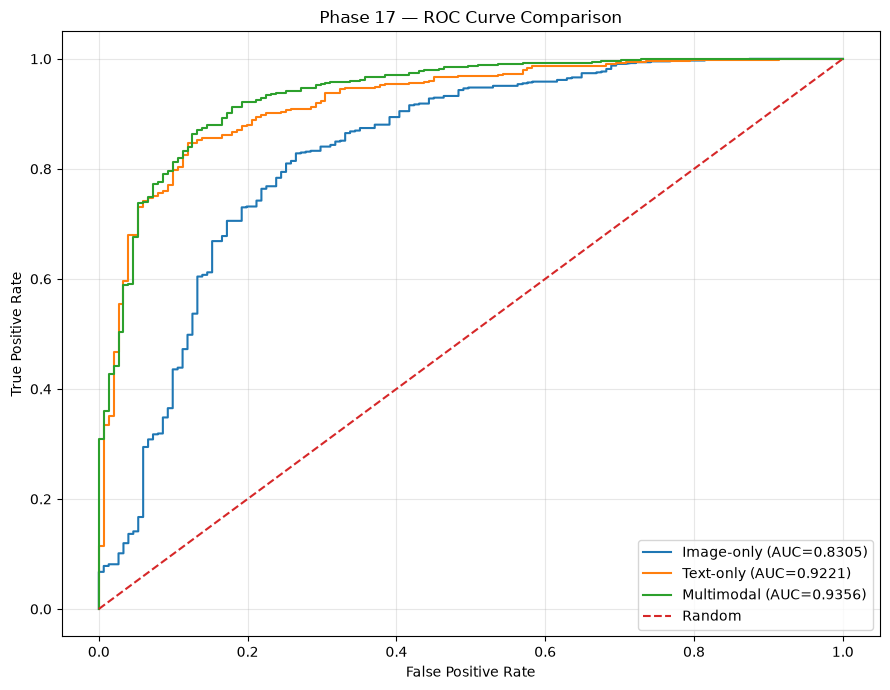


✓ ROC plot saved:
D:\downloads\misleading-health-infographic-detection\outputs\phase17\visualizations\roc_comparison.png


In [36]:
# ============================================================
# PHASE 17 — CELL 28
# ROC curve comparison
# ============================================================

print("=" * 70)
print("PHASE 17 — ROC CURVES")
print("=" * 70)


plt.figure(
    figsize=(9, 7)
)


# Image-only
image_fpr, image_tpr, _ = roc_curve(
    test_df["label"],
    image_test_probabilities
)

plt.plot(
    image_fpr,
    image_tpr,
    label=f"Image-only (AUC={image_roc_auc:.4f})"
)


# Text-only
text_fpr, text_tpr, _ = roc_curve(
    test_df["label"],
    text_test_probabilities
)

plt.plot(
    text_fpr,
    text_tpr,
    label=f"Text-only (AUC={text_roc_auc:.4f})"
)


# Multimodal
multimodal_fpr, multimodal_tpr, _ = roc_curve(
    test_df["label"],
    multimodal_test_probabilities
)

plt.plot(
    multimodal_fpr,
    multimodal_tpr,
    label=f"Multimodal (AUC={multimodal_roc_auc:.4f})"
)


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)


plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "Phase 17 — ROC Curve Comparison"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()


ROC_PATH = (
    PLOTS_DIR /
    "roc_comparison.png"
)


plt.savefig(
    ROC_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print()
print("✓ ROC plot saved:")
print(ROC_PATH)

PHASE 17 — PRECISION-RECALL CURVES


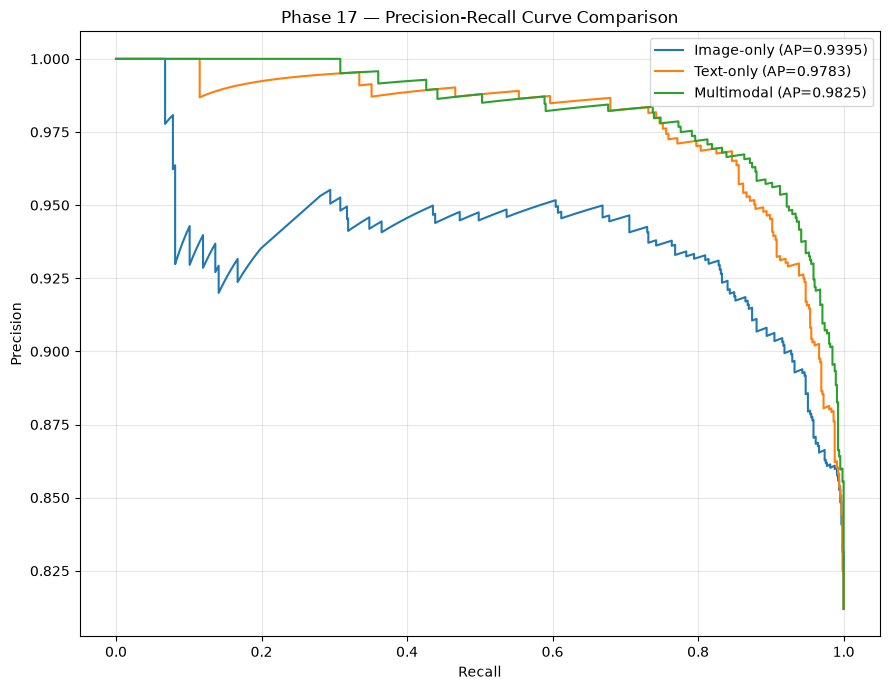


✓ Precision-Recall plot saved:
D:\downloads\misleading-health-infographic-detection\outputs\phase17\visualizations\precision_recall_comparison.png


In [37]:
# ============================================================
# PHASE 17 — CELL 29
# Precision-Recall curve comparison
# ============================================================

print("=" * 70)
print("PHASE 17 — PRECISION-RECALL CURVES")
print("=" * 70)


plt.figure(
    figsize=(9, 7)
)


# Image-only
image_precision_curve, image_recall_curve, _ = (
    precision_recall_curve(
        test_df["label"],
        image_test_probabilities
    )
)

plt.plot(
    image_recall_curve,
    image_precision_curve,
    label=f"Image-only (AP={image_pr_auc:.4f})"
)


# Text-only
text_precision_curve, text_recall_curve, _ = (
    precision_recall_curve(
        test_df["label"],
        text_test_probabilities
    )
)

plt.plot(
    text_recall_curve,
    text_precision_curve,
    label=f"Text-only (AP={text_pr_auc:.4f})"
)


# Multimodal
multimodal_precision_curve, multimodal_recall_curve, _ = (
    precision_recall_curve(
        test_df["label"],
        multimodal_test_probabilities
    )
)

plt.plot(
    multimodal_recall_curve,
    multimodal_precision_curve,
    label=f"Multimodal (AP={multimodal_pr_auc:.4f})"
)


plt.xlabel(
    "Recall"
)

plt.ylabel(
    "Precision"
)

plt.title(
    "Phase 17 — Precision-Recall Curve Comparison"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()


PR_PATH = (
    PLOTS_DIR /
    "precision_recall_comparison.png"
)


plt.savefig(
    PR_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print()
print("✓ Precision-Recall plot saved:")
print(PR_PATH)

PHASE 17 — MODEL METRIC VISUALIZATION


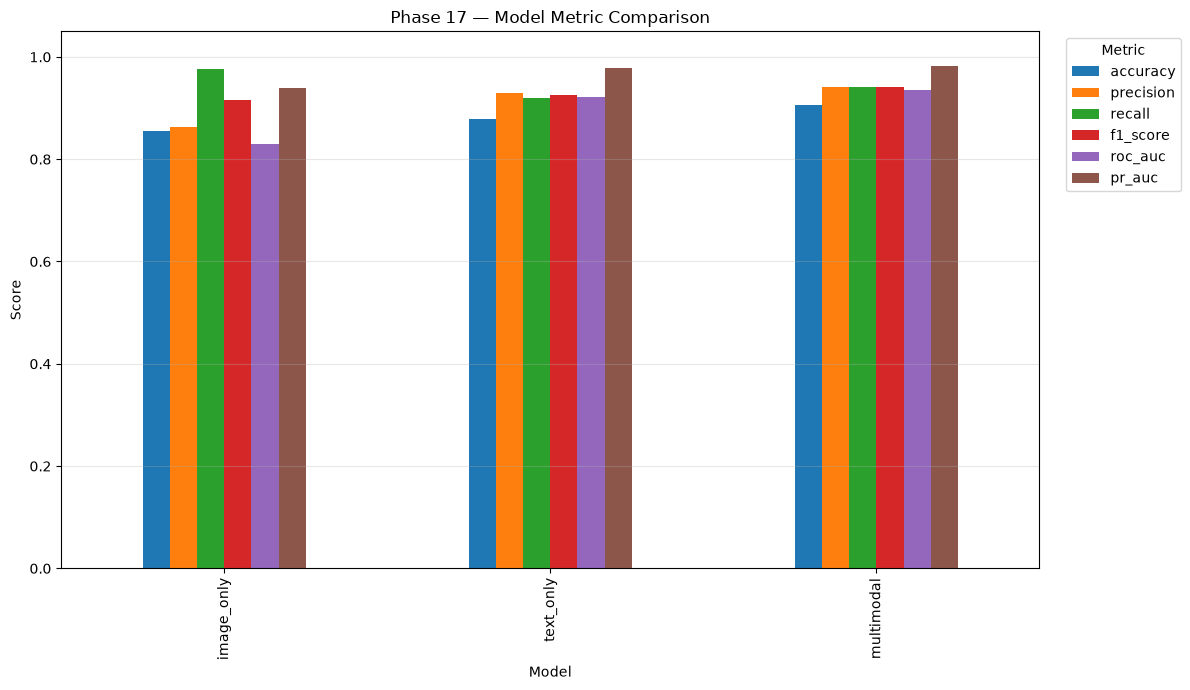


✓ Metric comparison plot saved:
D:\downloads\misleading-health-infographic-detection\outputs\phase17\visualizations\model_metric_comparison.png


In [38]:
# ============================================================
# PHASE 17 — CELL 30
# Model metric comparison visualization
# ============================================================

print("=" * 70)
print("PHASE 17 — MODEL METRIC VISUALIZATION")
print("=" * 70)


metrics_for_plot = [
    "accuracy",
    "precision",
    "recall",
    "f1_score",
    "roc_auc",
    "pr_auc"
]


plot_df = model_comparison.set_index(
    "model"
)[metrics_for_plot]


ax = plot_df.plot(
    kind="bar",
    figsize=(12, 7)
)


ax.set_xlabel(
    "Model"
)

ax.set_ylabel(
    "Score"
)

ax.set_title(
    "Phase 17 — Model Metric Comparison"
)

ax.set_ylim(
    0,
    1.05
)

ax.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.grid(
    axis="y",
    alpha=0.3
)


plt.tight_layout()


METRIC_COMPARISON_PATH = (
    PLOTS_DIR /
    "model_metric_comparison.png"
)


plt.savefig(
    METRIC_COMPARISON_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print()
print("✓ Metric comparison plot saved:")
print(METRIC_COMPARISON_PATH)

In [39]:
# ============================================================
# PHASE 17 — CELL 31
# Phase 16 deception-type analysis
# ============================================================

print("=" * 70)
print("PHASE 17 — DECEPTION TYPE ANALYSIS")
print("=" * 70)


PHASE16_MANIFEST = (
    PROJECT_ROOT /
    "outputs" /
    "phase16" /
    "manifests" /
    "deception_classification_manifest.csv"
)


assert PHASE16_MANIFEST.exists(), (
    f"Phase 16 manifest not found:\n"
    f"{PHASE16_MANIFEST}"
)


phase16_df = pd.read_csv(
    PHASE16_MANIFEST
)


print()
print(
    "Phase 16 records:",
    len(phase16_df)
)

print()
print(
    "Columns:"
)

print(
    phase16_df.columns.tolist()
)


# ------------------------------------------------------------
# Classification by label
# ------------------------------------------------------------

if {
    "label",
    "primary_deception_type"
}.issubset(
    phase16_df.columns
):

    deception_type_by_label = (
        pd.crosstab(
            phase16_df["primary_deception_type"],
            phase16_df["label"]
        )
        .reset_index()
    )

    DECEPTION_LABEL_PATH = (
        METRICS_DIR /
        "phase16_deception_type_by_label.csv"
    )

    deception_type_by_label.to_csv(
        DECEPTION_LABEL_PATH,
        index=False
    )

    print()
    print(
        "Deception type by label:"
    )

    display(
        deception_type_by_label
    )

    print()
    print(
        "✓ Saved:",
        DECEPTION_LABEL_PATH
    )


# ------------------------------------------------------------
# Evidence score summary
# ------------------------------------------------------------

evidence_columns = [
    "primary_deception_type",
    "classification_confidence",
    "best_evidence_score",
    "mean_evidence_score"
]


available_evidence_columns = [
    column
    for column in evidence_columns
    if column in phase16_df.columns
]


if (
    "primary_deception_type"
    in phase16_df.columns
):

    summary_agg = {}

    if (
        "classification_confidence"
        in phase16_df.columns
    ):
        summary_agg[
            "classification_confidence"
        ] = "mean"

    if (
        "best_evidence_score"
        in phase16_df.columns
    ):
        summary_agg[
            "best_evidence_score"
        ] = "mean"

    if (
        "mean_evidence_score"
        in phase16_df.columns
    ):
        summary_agg[
            "mean_evidence_score"
        ] = "mean"


    if summary_agg:

        deception_evidence_summary = (
            phase16_df
            .groupby(
                "primary_deception_type"
            )
            .agg(summary_agg)
            .reset_index()
        )

        DECEPTION_EVIDENCE_PATH = (
            METRICS_DIR /
            "deception_type_evidence_summary.csv"
        )

        deception_evidence_summary.to_csv(
            DECEPTION_EVIDENCE_PATH,
            index=False
        )

        print()
        print(
            "Deception/evidence summary:"
        )

        display(
            deception_evidence_summary
        )

        print()
        print(
            "✓ Saved:",
            DECEPTION_EVIDENCE_PATH
        )


print()
print(
    "NOTE: Phase 16 deception types are descriptive"
)

print(
    "rule-based candidate classifications and are"
)

print(
    "not treated as independently validated ground truth."
)

PHASE 17 — DECEPTION TYPE ANALYSIS

Phase 16 records: 14

Columns:
['claim_id', 'record_key', 'image_path', 'label', 'source', 'phase11_split', 'claim_text', 'claim_type', 'evidence_count', 'best_evidence_score', 'mean_evidence_score', 'evidence_sources', 'evidence_text', 'evidence_titles', 'overlap_terms', 'quantitative_patterns', 'deception_types', 'trigger_patterns', 'classification_confidence', 'primary_deception_type', 'classification_explanation']

Deception type by label:


label,primary_deception_type,0,1
0,NO_CLEAR_DECEPTION_PATTERN,1,1
1,PROMOTIONAL_OR_PERSUASIVE,1,1
2,QUANTITATIVE_OR_STATISTICAL_CLAIM,5,5



✓ Saved: D:\downloads\misleading-health-infographic-detection\outputs\phase17\metrics\phase16_deception_type_by_label.csv

Deception/evidence summary:


,primary_deception_type,classification_confidence,best_evidence_score,mean_evidence_score
0,NO_CLEAR_DECEPTION_PATTERN,0.20,0.8571,0.57142
1,PROMOTIONAL_OR_PERSUASIVE,0.70,0.0000,0.00000
2,QUANTITATIVE_OR_STATISTICAL_CLAIM,0.61,0.5000,0.40000



✓ Saved: D:\downloads\misleading-health-infographic-detection\outputs\phase17\metrics\deception_type_evidence_summary.csv

NOTE: Phase 16 deception types are descriptive
rule-based candidate classifications and are
not treated as independently validated ground truth.


In [40]:
# ============================================================
# PHASE 17 — CELL 32
# Save final metrics JSON
# ============================================================

print("=" * 70)
print("PHASE 17 — FINAL METRICS")
print("=" * 70)


phase17_metrics = {

    "phase": 17,

    "description": (
        "Ablation and comparative evaluation "
        "of image-only, text-only and multimodal models."
    ),

    "evaluation_protocol": {

        "threshold_selection": (
            "Validation set only; threshold selected "
            "by maximum F1."
        ),

        "test_set": (
            "Untouched during threshold selection."
        ),

        "leakage_control": (
            "Phase 11 leakage-safe train/validation/test splits."
        )
    },

    "dataset_sizes": {

        "train": int(len(train_df)),

        "validation": int(len(val_df)),

        "test": int(len(test_df))
    },

    "models": {

        "image_only": image_metrics,

        "text_only": text_metrics,

        "multimodal": multimodal_metrics
    },

    "phase11_reference": phase11_metrics,

    "ablation_gains": (
        ablation_gains_df
        .to_dict(orient="records")
    )
}


PHASE17_METRICS_PATH = (
    METRICS_DIR /
    "phase17_metrics.json"
)


with open(
    PHASE17_METRICS_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        phase17_metrics,
        f,
        indent=4
    )


print()
print(
    "✓ Final metrics saved:"
)

print(
    PHASE17_METRICS_PATH
)


print()
print(
    json.dumps(
        phase17_metrics,
        indent=4
    )
)

PHASE 17 — FINAL METRICS

✓ Final metrics saved:
D:\downloads\misleading-health-infographic-detection\outputs\phase17\metrics\phase17_metrics.json

{
    "phase": 17,
    "description": "Ablation and comparative evaluation of image-only, text-only and multimodal models.",
    "evaluation_protocol": {
        "threshold_selection": "Validation set only; threshold selected by maximum F1.",
        "test_set": "Untouched during threshold selection.",
        "leakage_control": "Phase 11 leakage-safe train/validation/test splits."
    },
    "dataset_sizes": {
        "train": 4016,
        "validation": 803,
        "test": 803
    },
    "models": {
        "image_only": {
            "model": "image_only",
            "threshold": 0.43999999999999984,
            "accuracy": 0.8542963885429639,
            "precision": 0.8629579375848032,
            "recall": 0.9754601226993865,
            "f1_score": 0.9157667386609071,
            "roc_auc": 0.8304808434567098,
            "pr_auc":

In [41]:
# ============================================================
# PHASE 17 — CELL 33
# Generate Phase 17 report
# ============================================================

print("=" * 70)
print("PHASE 17 — REPORT GENERATION")
print("=" * 70)


REPORT_PATH = (
    REPORT_DIR /
    "phase17_report.txt"
)


with open(
    REPORT_PATH,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "PHASE 17 — ABLATION AND COMPARATIVE EVALUATION\n"
    )

    f.write(
        "=" * 70 + "\n\n"
    )


    f.write(
        "1. OBJECTIVE\n"
    )

    f.write(
        "Phase 17 compares image-only, text-only and "
        "multimodal models using the leakage-safe Phase 11 "
        "dataset splits.\n\n"
    )


    f.write(
        "2. DATASET\n"
    )

    f.write(
        f"Training samples   : {len(train_df)}\n"
    )

    f.write(
        f"Validation samples : {len(val_df)}\n"
    )

    f.write(
        f"Test samples       : {len(test_df)}\n\n"
    )


    f.write(
        "3. THRESHOLD SELECTION\n"
    )

    f.write(
        "Classification thresholds were selected using "
        "validation-set F1 only. The selected thresholds "
        "were then applied unchanged to the untouched test set.\n\n"
    )


    f.write(
        "4. MODEL RESULTS\n"
    )

    f.write(
        "-" * 70 + "\n"
    )


    for _, row in model_comparison.iterrows():

        f.write(
            f"\nModel: {row['model']}\n"
        )

        f.write(
            f"Threshold : {row['threshold']:.4f}\n"
        )

        f.write(
            f"Accuracy  : {row['accuracy']:.4f}\n"
        )

        f.write(
            f"Precision : {row['precision']:.4f}\n"
        )

        f.write(
            f"Recall    : {row['recall']:.4f}\n"
        )

        f.write(
            f"F1-score  : {row['f1_score']:.4f}\n"
        )

        f.write(
            f"ROC-AUC   : {row['roc_auc']:.4f}\n"
        )

        f.write(
            f"PR-AUC    : {row['pr_auc']:.4f}\n"
        )


    f.write(
        "\n"
    )

    f.write(
        "5. ABLATION GAINS\n"
    )

    f.write(
        "-" * 70 + "\n"
    )


    for _, row in ablation_gains_df.iterrows():

        f.write(
            f"{row['metric']}:\n"
        )

        f.write(
            f"  Multimodal - Image-only: "
            f"{row['multimodal_minus_image']:+.4f}\n"
        )

        f.write(
            f"  Multimodal - Text-only : "
            f"{row['multimodal_minus_text']:+.4f}\n"
        )


    f.write(
        "\n"
    )

    f.write(
        "6. PHASE 16 DECEPTION ANALYSIS\n"
    )

    f.write(
        "Phase 16 deception types are included as "
        "descriptive rule-based candidate classifications. "
        "They are not treated as independently validated "
        "ground truth labels.\n\n"
    )


    f.write(
        "7. OUTPUT ARTIFACTS\n"
    )

    f.write(
        f"Metrics directory : {METRICS_DIR}\n"
    )

    f.write(
        f"Plots directory   : {PLOTS_DIR}\n"
    )

    f.write(
        f"Report directory  : {REPORT_DIR}\n"
    )


print()
print(
    "✓ Phase 17 report generated:"
)

print(
    REPORT_PATH
)

PHASE 17 — REPORT GENERATION

✓ Phase 17 report generated:
D:\downloads\misleading-health-infographic-detection\outputs\phase17\reports\phase17_report.txt


In [42]:
# ============================================================
# PHASE 17 — CELL 34
# Final artifact verification
# ============================================================

print("=" * 70)
print("PHASE 17 — FINAL ARTIFACT VERIFICATION")
print("=" * 70)


expected_files = [

    # Models
    ABLATION_DIR /
    "best_text_only.weights.h5",

    # Metrics
    METRICS_DIR /
    "image_only_training_history.csv",

    METRICS_DIR /
    "text_only_training_history.csv",

    METRICS_DIR /
    "image_only_validation_thresholds.csv",

    METRICS_DIR /
    "text_only_validation_thresholds.csv",

    METRICS_DIR /
    "multimodal_validation_thresholds.csv",

    METRICS_DIR /
    "image_only_confusion_matrix.csv",

    METRICS_DIR /
    "text_only_confusion_matrix.csv",

    METRICS_DIR /
    "multimodal_confusion_matrix.csv",

    METRICS_DIR /
    "model_comparison.csv",

    METRICS_DIR /
    "multimodal_ablation_gains.csv",

    METRICS_DIR /
    "phase17_metrics.json",

    # Visualizations
    PLOTS_DIR /
    "roc_comparison.png",

    PLOTS_DIR /
    "precision_recall_comparison.png",

    PLOTS_DIR /
    "model_metric_comparison.png",

    # Report
    REPORT_DIR /
    "phase17_report.txt"
]


verification_rows = []


for path in expected_files:

    verification_rows.append({

        "artifact": str(path),

        "exists": path.exists(),

        "size_bytes": (
            path.stat().st_size
            if path.exists()
            else 0
        )
    })


verification_df = pd.DataFrame(
    verification_rows
)


display(
    verification_df
)


missing_files = verification_df[
    ~verification_df["exists"]
]


print()


if len(missing_files) == 0:

    print("=" * 70)
    print("✓ PHASE 17 COMPLETED SUCCESSFULLY")
    print("=" * 70)

else:

    print(
        "WARNING — Missing artifacts:"
    )

    display(
        missing_files
    )

PHASE 17 — FINAL ARTIFACT VERIFICATION


,artifact,exists,size_bytes
0,D:\downloads\misleading-health-infographic-det...,True,32255512
1,D:\downloads\misleading-health-infographic-det...,True,3334
2,D:\downloads\misleading-health-infographic-det...,True,2015
3,D:\downloads\misleading-health-infographic-det...,True,7689
4,D:\downloads\misleading-health-infographic-det...,True,7758
5,D:\downloads\misleading-health-infographic-det...,True,7732
6,D:\downloads\misleading-health-infographic-det...,True,60
7,D:\downloads\misleading-health-infographic-det...,True,60
8,D:\downloads\misleading-health-infographic-det...,True,60
9,D:\downloads\misleading-health-infographic-det...,True,484



✓ PHASE 17 COMPLETED SUCCESSFULLY
